# Dynamic model of a serial manipulator with `moro`

This notebook shows how to compute the dynamic model of a serial manipulator using `moro`.

As a working example, we use a planar **RR manipulator**: a two-link robot with two revolute joints. The goal is to obtain the model in the standard matrix form

$$
M(q)\ddot{q} + C(q,\dot{q})\dot{q} + G(q) = \tau,
$$

where:

| Symbol | Meaning |
|---|---|
| $q$ | vector of generalized coordinates |
| $\dot{q}$ | vector of generalized velocities |
| $\ddot{q}$ | vector of generalized accelerations |
| $M(q)$ | inertia matrix |
| $C(q,\dot{q})$ | Coriolis/centrifugal matrix |
| $G(q)$ | gravity torque vector |
| $\tau$ | vector of generalized forces or torques |

## Euler-Lagrange formulation

`moro` computes the dynamic model symbolically using the Euler-Lagrange formulation. For each generalized coordinate $q_i$, the equation of motion is

$$
\frac{d}{dt}\left(\frac{\partial \mathcal{L}}{\partial \dot{q}_i}\right)
- \frac{\partial \mathcal{L}}{\partial q_i} = \tau_i,
$$

where the Lagrangian is

$$
\mathcal{L} = \mathcal{K} - \mathcal{P}.
$$

Here, $\mathcal{K}$ is the total kinetic energy and $\mathcal{P}$ is the total potential energy.

## Setup

We import SymPy for symbolic manipulation, the main `moro` package, and predefined symbolic variables from `moro.abc`.

For dynamic modeling, it is important to use time-dependent generalized coordinates. In `moro.abc`, variables such as `q1` and `q2` are dynamic symbols: $q_1(t)$ and $q_2(t)$.

In [4]:
import sympy as sp
from IPython.display import Math, display

import moro as mr
from moro.abc import t, q1, q2, m1, m2, l1, l2, lc1, lc2, g
mr.enable_vprinting()

# Define the RR manipulator

The RR manipulator is defined using Denavit--Hartenberg parameters. Each row passed to `Robot` has the form:

$$
(a_i, \alpha_i, d_i, \theta_i, \text{joint type}).
$$

For the planar RR manipulator:

| Link | $a_i$ | $\alpha_i$ | $d_i$ | $\theta_i$ | Joint type |
|---|---:|---:|---:|---:|---|
| 1 | $l_1$ | $0$ | $0$ | $q_1$ | `"r"` |
| 2 | $l_2$ | $0$ | $0$ | $q_2$ | `"r"` |

The joint type `"r"` indicates a revolute joint.

In [6]:
RR = mr.Robot(
    (l1, 0, 0, q1, "r"),
    (l2, 0, 0, q2, "r"),
)

RR

Robot RR

# Assign dynamic parameters

To compute a dynamic model, `moro` needs:

1. Link masses.
2. Link inertia tensors with respect to frames located at the centers of mass and aligned with each link frame.
3. Center-of-mass positions expressed in the corresponding link frames.
4. Gravity acceleration expressed in the base frame.

For this example, we keep the parameters symbolic.

## Link masses

The masses are assigned with the `masses` property.

In [9]:
RR.masses = [m1, m2]

print("Link masses:")
display(RR.masses)

Link masses:


## Inertia tensors

The property `inertia_tensors` expects one $3\times3$ matrix per link. If we assign `None`, `moro` automatically creates diagonal symbolic inertia tensors of the form

$$
I_i = \operatorname{diag}(I_{x_i x_i}, I_{y_i y_i}, I_{z_i z_i}).
$$

For a planar RR manipulator moving in the $xy$ plane, the most visible rotational inertia term is usually the one about $z$, but keeping the full diagonal symbolic tensors is general and convenient.

Inertia tensor of link 1:


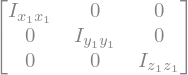

Inertia tensor of link 2:


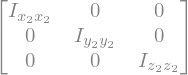

In [11]:
RR.inertia_tensors = None

print("Inertia tensor of link 1:")
display(RR.I_cm(1))

print("Inertia tensor of link 2:")
display(RR.I_cm(2))

## Center-of-mass positions

The center of mass of each link must be expressed with respect to its own link frame.

For the RR manipulator, the link frames are located at the distal end of each link according to the DH convention used here. Therefore, if $l_{c1}$ and $l_{c2}$ are distances from the proximal joint to each center of mass, the CoM locations with respect to frames `{1}` and `{2}` are

$$
r_{G_1}^{1} = \begin{bmatrix}-(l_1-l_{c1})\\0\\0\end{bmatrix},
\qquad
r_{G_2}^{2} = \begin{bmatrix}-(l_2-l_{c2})\\0\\0\end{bmatrix}.
$$

Center-of-mass position of link 1 in frame {1}:


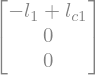

Center-of-mass position of link 2 in frame {2}:


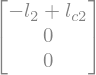

In [13]:
rG11 = [-(l1 - lc1), 0, 0]  # CoM of link 1 expressed in frame {1}
rG22 = [-(l2 - lc2), 0, 0]  # CoM of link 2 expressed in frame {2}

RR.cm_positions = [rG11, rG22]

print("Center-of-mass position of link 1 in frame {1}:")
display(RR.cm_positions[0])

print("Center-of-mass position of link 2 in frame {2}:")
display(RR.cm_positions[1])

## Gravity vector

The gravity vector is expressed in the base frame `{0}`. In this example, gravity points in the negative $y$ direction:

$$
g^0 = \begin{bmatrix}0\\-g\\0\end{bmatrix}.
$$

Gravity vector expressed in the base frame:


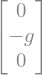

In [15]:
RR.gravity = [0, -g, 0]

print("Gravity vector expressed in the base frame:")
display(RR.gravity)

## Model summary

`model_summary()` gives a compact report of the robot model and which dynamic quantities have been explicitly defined or automatically assumed.

In [17]:
print(RR.model_summary())

Model summary | Robot RR | DOF = 2
  joint_limits     : default
  masses           : explicit
  inertia_tensors  : assumed (diagonal symbolic)
  cm_positions     : explicit
  gravity          : explicit


# Center-of-mass kinematics

The dynamic model depends on the velocity of each center of mass and on each link angular velocity. We can inspect the center-of-mass positions expressed in the base frame.

<IPython.core.display.Math object>

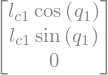

<IPython.core.display.Math object>

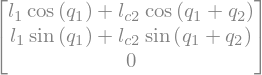

In [19]:
display(Math(r"r_{G_1}^0 ="))
display(RR.r_cm(1))

display(Math(r"r_{G_2}^0 ="))
display(RR.r_cm(2))

The corresponding linear velocities are obtained by differentiating with respect to time.

<IPython.core.display.Math object>

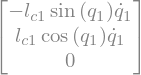

<IPython.core.display.Math object>

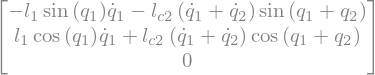

In [21]:
display(Math(r"v_{G_1}^0 ="))
display(RR.v_cm(1))

display(Math(r"v_{G_2}^0 ="))
display(RR.v_cm(2))

# Energy functions

`moro` can compute the kinetic and potential energy of each link, as well as the total kinetic and potential energy of the robot.

## Kinetic energy

For each link,

$$
\mathcal{K}_i = \frac{1}{2}m_i v_{G_i}^T v_{G_i}
+ \frac{1}{2}\omega_i^T I_i \omega_i.
$$

In [24]:
# Individual energy methods are available if you need the full expressions:
# RR.link_kinetic_energy(1), RR.link_kinetic_energy(2), RR.kinetic_energy()
#
# For symbolic manipulators, these expressions can become large.
# In this notebook, we continue with the matrix-form model, which is the
# most compact representation for control and simulation.
print("Kinetic energy methods available:")
print("- RR.link_kinetic_energy(i)")
print("- RR.kinetic_energy()")

Kinetic energy methods available:
- RR.link_kinetic_energy(i)
- RR.kinetic_energy()


## Potential energy

For each link, `moro` uses

$$
\mathcal{P}_i = -m_i (g^0)^T r_{G_i}^{0}.
$$

In [26]:
P1 = RR.link_potential_energy(1)
P2 = RR.link_potential_energy(2)
P = RR.potential_energy()

display(Math(r"\mathcal{P}_1 ="))
display(P1[0])

display(Math(r"\mathcal{P}_2 ="))
display(P2[0])

display(Math(r"\mathcal{P} = \mathcal{P}_1 + \mathcal{P}_2 ="))
display(P[0])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Lagrangian

The Lagrangian is

$$
\mathcal{L} = \mathcal{K} - \mathcal{P}.
$$

In [28]:
# The Lagrangian can be obtained with:
# L = RR.lagrangian()
#
# We avoid expanding it here because the matrix form M(q), C(q, qdot), G(q)
# is usually easier to read for the RR manipulator.
print("Lagrangian method available:")
print("- RR.lagrangian()")

Lagrangian method available:
- RR.lagrangian()


# Dynamic model in matrix form

The matrix form of the dynamic model is

$$
M(q)\ddot{q} + C(q,\dot{q})\dot{q} + G(q) = \tau.
$$

`moro` provides the components through:

| Method | Returned object |
|---|---|
| `inertia_matrix()` | $M(q)$ |
| `coriolis_matrix()` | $C(q,\dot{q})$ |
| `gravity_vector()` | $G(q)$ |
| `dynamic_model_matrix_form()` | symbolic matrix equation |

## Inertia matrix $M(q)$

<IPython.core.display.Math object>

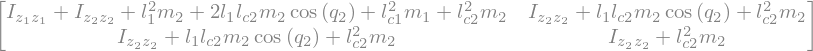

In [31]:
M = RR.inertia_matrix()

display(Math(r"M(q) ="))
display(M)

## Coriolis/centrifugal matrix $C(q,\dot{q})$

<IPython.core.display.Math object>

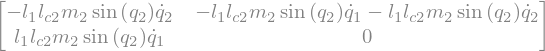

In [33]:
C = RR.coriolis_matrix()

display(Math(r"C(q,\dot{q}) ="))
display(C)

## Gravity torque vector $G(q)$

<IPython.core.display.Math object>

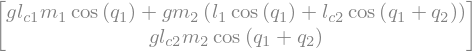

In [35]:
G = RR.gravity_vector()

display(Math(r"G(q) ="))
display(G)

## Complete matrix equation

Finally, `dynamic_model_matrix_form()` returns the equation

$$
M(q)\ddot{q} + C(q,\dot{q})\dot{q} + G(q) = \tau.
$$

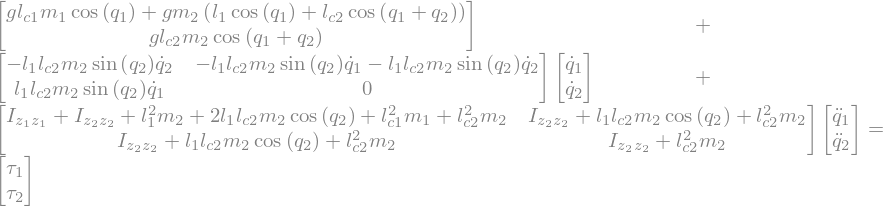

In [37]:
matrix_model = RR.dynamic_model_matrix_form()

display(matrix_model)

# Euler-Lagrange equations joint by joint

If you want the equations obtained directly from the Euler--Lagrange expression, use `dynamic_model()`. It returns one equation per joint.

In [39]:
# Joint-by-joint Euler--Lagrange equations are available with:
# equations = RR.dynamic_model()
#
# For compactness, we keep the displayed result in matrix form above.
print("Euler--Lagrange equation method available:")
print("- RR.dynamic_model()")

Euler--Lagrange equation method available:
- RR.dynamic_model()


# Optional numerical substitution

The symbolic model can be evaluated by substituting numerical values. Below we substitute simple values for link lengths, center-of-mass distances, masses, gravity, and inertias.

This does not simulate the robot; it only evaluates the symbolic matrices at a particular configuration and velocity.

<IPython.core.display.Math object>

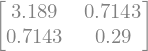

<IPython.core.display.Math object>

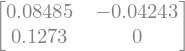

<IPython.core.display.Math object>

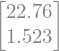

In [41]:
inertia_symbols = sorted(
    list(M.free_symbols | C.free_symbols | G.free_symbols),
    key=lambda symbol: symbol.name,
)
inertia_symbols = [symbol for symbol in inertia_symbols if symbol.name.startswith("I_")]

numeric_values = {
    l1: 1.0,
    l2: 0.8,
    lc1: 0.5,
    lc2: 0.4,
    m1: 2.0,
    m2: 1.5,
    g: 9.81,
    q1: sp.pi / 6,
    q2: sp.pi / 4,
    sp.diff(q1, t): 0.3,
    sp.diff(q2, t): -0.2,
}

# Assign a small numerical value to every symbolic inertia term that appears.
for symbol in inertia_symbols:
    numeric_values[symbol] = 0.05

M_num = M.subs(numeric_values).evalf(4)
C_num = C.subs(numeric_values).evalf(4)
G_num = G.subs(numeric_values).evalf(4)

display(Math(r"M(q)\;\text{at the selected state} ="))
display(M_num)

display(Math(r"C(q,\dot{q})\;\text{at the selected state} ="))
display(C_num)

display(Math(r"G(q)\;\text{at the selected state} ="))
display(G_num)

# Conclusions

In this notebook, we used `moro` to compute the dynamic model of a planar RR manipulator. The workflow was:

1. Define the robot using DH parameters and joint types.
2. Assign masses, inertia tensors, center-of-mass positions, and gravity.
3. Inspect center-of-mass kinematics.
4. Compute kinetic energy, potential energy, and the Lagrangian.
5. Obtain $M(q)$, $C(q,\dot{q})$, $G(q)$, and the complete dynamic model.
6. Optionally evaluate the symbolic expressions at a numerical state.

The same workflow applies to other serial manipulators: define the kinematics first, then provide the dynamic parameters needed by the Euler--Lagrange formulation.